### #2 improvements
 - improve cutting out of mesh from uniform grid (no more external points) (get_grid_surface2())
 - same curvature values for every pose (poly fitted in neutral and interceps are transformed back to neutral)
 - n points per mm^2 () (get_grid_surface2() / get_grid2())
 - get congruence of every pose?

### #3 improvements
 - fit poynomial in centre norm based coordinate system for both surfaces (then transform interception points accordingly)

### #4 improvements
 - tried switching to trimesh for ray trace (*** something about how pyvista calculates ray_trace has broken in wristrepair environment - now 50x slower on mac) but trimesh was still slow
 - had to make new environment and keep using pyvista - TMCshape
 - changed get_intercepts so ray_start points are now 10 units further from mc1 so that areas that interfere are picked up
 - added option to 'normalise' or 'scale' k

### #5 improvements
 - (a) new congruence metric based on difference between shape operater matrices at each point (could do demonstration of C value for difference scenarios to better understand)
 - (b) new congruence metric based on both principal curvatures 

### Future improvements
 - equalateral mesh instead of grid for better uniform point density

# What's new
- updated version of TMC-SurfaceFitLocal-5b to work in WorkPackages environment with paths.py
- Also started using alternate neutral in available

In [6]:
import numpy as np
import pandas as pd
import pyvista as pv
from tqdm import tqdm
from pathlib import Path

from phd_helpers.paths import (
    transform_mesh, get_relative_transform_new_basis, get_db_path, get_info_df, get_subject_stl_path, get_bone_transforms, pose2idCMC, 
    transform_points, build_axes_from_vector
)

from phd_helpers.SurfaceFit import (
    get_grid_surface2, get_sp_terms, get_f, get_ks_eig, get_poly_normals, get_intercepts, get_centroid
)

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def get_subject_tpm_volume(info, subject, sideL):
    return info[(info['subject']==subject)&(info['side']==sideL)]['tpm_volume'].to_list()[0]

def get_polynomial_model(mesh, degree=5):
    points = mesh.points
    xs, ys, zs = points[:, 0], points[:, 1], points[:, 2]
    XY = np.vstack((xs, ys)).T

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    XY_poly = poly.fit_transform(XY) # 21 coefs for 5th degree polynomial
    model = LinearRegression(fit_intercept=True)
    model.fit(XY_poly, zs)

    # fit quality
    z_pred = model.predict(XY_poly)
    r2 = r2_score(zs, z_pred)
    rmse = np.sqrt(mean_squared_error(zs, z_pred))
    #print(f"Polynomial fit quality: R² = {r2:.4f}, RMSE = {rmse:.4f}")
    return model, poly, r2, rmse

def get_Ck(saddle_ks, mc1_ks, intercept_dists, d0=0.1):
    """get curvature congruence"""
    k1_T = saddle_ks['kmax']
    k2_T = saddle_ks['kmin']
    k1_M = mc1_ks['kmin']
    k2_M = mc1_ks['kmax']

    Cs = np.sqrt( ((k1_T+k1_M)**2 + (k2_T+k2_M)**2) / 2 )

    # d0 stops weights from blowing up due to interference
    weights = 1.0 / (intercept_dists + d0)
    weights /= weights.sum()          # normalize

    C_avg = np.sum(weights * Cs)
    return C_avg

def get_Cv(saddle_ks, mc1_ks, intercept_dists, d0=0.1, mode='squared'):
    """get vector congruence"""
    v1_T = saddle_ks['kmax_dir']
    v2_T = saddle_ks['kmin_dir']
    v1_M = mc1_ks['kmin_dir']
    v2_M = mc1_ks['kmax_dir']

    if mode == 'squared':
        # squared cosines (sign-invariant)
        C1s = np.sum(v1_T * v1_M, axis=1)**2
        C2s = np.sum(v2_T * v2_M, axis=1)**2
        Cs = 0.5 * (C1s + C2s)
    elif mode == 'abs':
        # (sign-invariant)
        C1s = np.abs(np.sum(v1_T * v1_M, axis=1))
        C2s = np.abs(np.sum(v2_T * v2_M, axis=1))
        Cs = 0.5 * (C1s + C2s)

    # d0 stops weights from blowing up due to interference
    weights = 1.0 / (intercept_dists + d0)
    weights /= weights.sum()          # normalize

    C_avg = np.sum(weights * Cs)
    return C_avg
######################## Maybe do hard cutoff at d = 0.1?  
# - where they interfere points that are through surface are further but should be closer

In [9]:
info = get_info_df()
db_path = get_db_path()
savename = 'SurfaceFit-abs.csv' ######### ------------ CHANGE ------------ ######### 

mc1_base_path = Path('../../data/mc1-base-meshes2')
mc1_mesh_files = list(mc1_base_path.glob('*.vtk'))
print(len(mc1_mesh_files), 'mc1s')

saddle_mesh_path = Path('../../data/saddle-meshes2')
saddle_mesh_files = list(saddle_mesh_path.glob('*.vtk'))
print(len(saddle_mesh_files), 'saddles')

46 mc1s
46 saddles


In [10]:
poly_degree = 5
n_points = 200
mc1_grid_points = n_points # points / mm^2
saddle_grid_points = n_points # points / mm^2
#n = 200 # points in rmsd neighbourhood
n_joints = len(saddle_mesh_files)
scale_k = 'scale' # set to either 'scale' or 'normalise' or anything else

poses = ['neutral', 'flexion', 'extension', 'abduction', 'adduction', 'pinch', 'grasp', 'jar', 'pinch_load', 'grasp_load', 'jar_load']
#poses = ['neutral', 'flexion']

data = info.copy()[info['group']=='CMC']
for k in ['tpm_kmin', 'tpm_kmax', 'mc1_kmin', 'mc1_kmax']:
    data[k] = np.zeros(n_joints)
for pose in poses:
    data[f'Ck_{pose}'] = np.zeros(n_joints)
    data[f'Cv_{pose}'] = np.zeros(n_joints)
data['tpm_r2'] = np.zeros(n_joints)
data['tpm_rmse'] = np.zeros(n_joints)
data['mc1_r2'] = np.zeros(n_joints)
data['mc1_rmse'] = np.zeros(n_joints)

vol_mean = data['tpm_volume'].mean()
for i in tqdm(range(n_joints)):
    saddle_filepath = saddle_mesh_files[i]
    subject, sideL, *_ = saddle_filepath.name.split('-')
    subject = int(subject)
    vol = get_subject_tpm_volume(info, subject, sideL)
    stl_path = get_subject_stl_path(subject, sideL)

    # get saddle mesh
    saddle_mesh = pv.read(saddle_filepath).extract_surface(algorithm=None)

    # get mc1 mesh
    mc1_filepath = [x for x in mc1_mesh_files if str(subject) in x.name and sideL in x.name][0]
    mc1_neutral_mesh = pv.read(mc1_filepath).extract_surface(algorithm=None)


    # get saddle normal based axes - **** could determine orientation that minimises z gradients? ****
    saddle_centre_idx = saddle_mesh.find_closest_point(get_centroid(saddle_mesh.faces.reshape(-1, 4), saddle_mesh.points))
    saddle_centre_norm = saddle_mesh.compute_normals(point_normals=True, cell_normals=False).point_data["Normals"][saddle_centre_idx]
    saddle_norm_axes = build_axes_from_vector(saddle_centre_norm*(-1))
    saddle_norm_origin = saddle_mesh.points[saddle_centre_idx] - 5 * saddle_centre_norm # 5 is avg norm of: saddle_centre - tpm_centroid
    # get mc1 normal based axes
    mc1_centre_idx = mc1_neutral_mesh.find_closest_point(get_centroid(mc1_neutral_mesh.faces.reshape(-1, 4), mc1_neutral_mesh.points))
    mc1_centre_norm = mc1_neutral_mesh.compute_normals(point_normals=True, cell_normals=False).point_data["Normals"][mc1_centre_idx]
    mc1_norm_axes = build_axes_from_vector(mc1_centre_norm*(-1))
    mc1_norm_origin = mc1_neutral_mesh.points[mc1_centre_idx] - 5 * mc1_centre_norm # 5 is avg norm of: saddle_centre - tpm_centroid
    # change to centre normal based coordinate system for good polynomial fit
    saddle_mesh = transform_mesh(saddle_mesh, saddle_norm_axes, saddle_norm_origin, inverse=True)
    mc1_neutral_mesh = transform_mesh(mc1_neutral_mesh, mc1_norm_axes, mc1_norm_origin, inverse=True)


    # fit models
    saddle_model, saddle_poly, saddle_r2, saddle_rmse = get_polynomial_model(saddle_mesh, degree=poly_degree)
    mc1_model, mc1_poly, mc1_r2, mc1_rmse = get_polynomial_model(mc1_neutral_mesh, degree=poly_degree)
    data.loc[(data.subject==subject)&(data.side==sideL),'tpm_r2']=saddle_r2
    data.loc[(data.subject==subject)&(data.side==sideL),'tpm_rmse']=saddle_rmse
    data.loc[(data.subject==subject)&(data.side==sideL),'mc1_r2']=mc1_r2
    data.loc[(data.subject==subject)&(data.side==sideL),'mc1_rmse']=mc1_rmse

    # get grid of x, y points within bounds of mesh
    mc1_grid_surface_neutral = get_grid_surface2(mc1_neutral_mesh, mc1_model, mc1_poly, grid_points=mc1_grid_points)
    saddle_grid_surface = get_grid_surface2(saddle_mesh, saddle_model, saddle_poly, grid_points=saddle_grid_points)

    # Evaluate curvatures on the evenly spaced grids
    saddle_terms = get_sp_terms(saddle_poly)
    saddle_f = get_f(saddle_model, saddle_terms)
    saddle_ks = get_ks_eig(saddle_f, saddle_grid_surface.points)
    if scale_k == 'normalise':
        saddle_ks['kmin'] = saddle_ks['kmin'] * vol**(1/3) 
        saddle_ks['kmax'] = saddle_ks['kmax'] * vol**(1/3) 
    elif scale_k == 'scale':
        saddle_ks['kmin'] = saddle_ks['kmin'] / (vol_mean / vol)**(1/3) 
        saddle_ks['kmax'] = saddle_ks['kmax'] / (vol_mean / vol)**(1/3) 

    mc1_terms = get_sp_terms(mc1_poly)
    mc1_f = get_f(mc1_model, mc1_terms)
    mc1_ks = get_ks_eig(mc1_f, mc1_grid_surface_neutral.points)
    if scale_k == 'normalise':
        mc1_ks['kmin'] = mc1_ks['kmin'] * vol**(1/3) 
        mc1_ks['kmax'] = mc1_ks['kmax'] * vol**(1/3) 
    elif scale_k == 'scale':
        mc1_ks['kmin'] = mc1_ks['kmin'] / (vol_mean / vol)**(1/3) 
        mc1_ks['kmax'] = mc1_ks['kmax'] / (vol_mean / vol)**(1/3) 


    # get average kmins and kmaxs
    tpm_kmin = np.mean(saddle_ks['kmin'])
    tpm_kmax = np.mean(saddle_ks['kmax'])
    mc1_kmin = np.mean(mc1_ks['kmin'])
    mc1_kmax = np.mean(mc1_ks['kmax'])
    data.loc[(data.subject==subject)&(data.side==sideL),'tpm_kmin']=tpm_kmin
    data.loc[(data.subject==subject)&(data.side==sideL),'tpm_kmax']=tpm_kmax
    data.loc[(data.subject==subject)&(data.side==sideL),'mc1_kmin']=mc1_kmin
    data.loc[(data.subject==subject)&(data.side==sideL),'mc1_kmax']=mc1_kmax

    # get saddle normals
    saddle_grid_normals = get_poly_normals(saddle_f, saddle_grid_surface.points)

    # change surface mesh coords back to global frame for calculating intercepts
    saddle_grid_surface = transform_mesh(saddle_grid_surface, saddle_norm_axes, saddle_norm_origin, inverse=False)
    mc1_grid_surface_neutral = transform_mesh(mc1_grid_surface_neutral, mc1_norm_axes, mc1_norm_origin, inverse=False)
    saddle_grid_surface_points = saddle_grid_surface.points
    saddle_grid_normals = transform_points(saddle_grid_normals, saddle_norm_axes, np.zeros(3), inverse=False)


    for pose in poses:
        
        # position mc1 surface
        #pose_id = None if pose=='neutral' else pose2idCMC(pose)
        pose_id = pose2idCMC(pose)
        try: # if subject has alternate neutral that will be used otherwise Exception and use default neutral
            transforms = get_bone_transforms(pose_id, stl_path)
            R_rel, t_rel = get_relative_transform_new_basis(transforms, 'mc1', 'tpm') # global
        except:
            R_rel, t_rel = np.eye(3), np.zeros(3)

        mc1_grid_surface = transform_mesh(mc1_grid_surface_neutral, R_rel, t_rel)

        # find intercepts
        mc1_grid_intercepts, saddle_grid_intercepts, intercept_mask = get_intercepts(
                                                                                mc1_grid_surface, 
                                                                                saddle_grid_surface_points, 
                                                                                saddle_grid_normals,
                                                                                offset=10
                                                                                )
        
        # get distances between intercept points before converting to neutral pose coords
        intercept_dists = np.linalg.norm(saddle_grid_intercepts - mc1_grid_intercepts, axis=1)
        # convert back to neutral pose coords
        mc1_grid_intercepts = transform_points(mc1_grid_intercepts, R_rel, t_rel, inverse=True)
        # convert back to centre normal based coords
        saddle_grid_intercepts = transform_points(saddle_grid_intercepts, saddle_norm_axes, saddle_norm_origin, inverse=True)
        mc1_grid_intercepts = transform_points(mc1_grid_intercepts, mc1_norm_axes, mc1_norm_origin, inverse=True)


        # get ks of intercepts
        saddle_intercept_ks = get_ks_eig(saddle_f, saddle_grid_intercepts)
        mc1_intercept_ks = get_ks_eig(mc1_f, mc1_grid_intercepts)

        if scale_k == 'normalise':
            saddle_intercept_ks['kmax'] = saddle_intercept_ks['kmax'] * vol**(1/3) 
            saddle_intercept_ks['kmin'] = saddle_intercept_ks['kmin'] * vol**(1/3) 
            mc1_intercept_ks['kmax'] = mc1_intercept_ks['kmax'] * vol**(1/3) 
            mc1_intercept_ks['kmin'] = mc1_intercept_ks['kmin'] * vol**(1/3) 
        elif scale_k == 'scale':
            saddle_intercept_ks['kmax'] = saddle_intercept_ks['kmax'] / (vol_mean / vol)**(1/3) 
            saddle_intercept_ks['kmin'] = saddle_intercept_ks['kmin'] / (vol_mean / vol)**(1/3) 
            mc1_intercept_ks['kmax'] = mc1_intercept_ks['kmax'] / (vol_mean / vol)**(1/3) 
            mc1_intercept_ks['kmin'] = mc1_intercept_ks['kmin'] / (vol_mean / vol)**(1/3) 

        # convert k vectors back to global posed coords
        saddle_intercept_ks['kmax_dir'] = transform_points(saddle_intercept_ks['kmax_dir'], saddle_norm_axes, np.zeros(3), inverse=False)
        saddle_intercept_ks['kmin_dir'] = transform_points(saddle_intercept_ks['kmin_dir'], saddle_norm_axes, np.zeros(3), inverse=False)

        mc1_intercept_ks['kmax_dir'] = transform_points(mc1_intercept_ks['kmax_dir'], mc1_norm_axes, np.zeros(3), inverse=False)
        mc1_intercept_ks['kmin_dir'] = transform_points(mc1_intercept_ks['kmin_dir'], mc1_norm_axes, np.zeros(3), inverse=False)
        mc1_intercept_ks['kmax_dir'] = transform_points(mc1_intercept_ks['kmax_dir'], R_rel, np.zeros(3), inverse=False)
        mc1_intercept_ks['kmin_dir'] = transform_points(mc1_intercept_ks['kmin_dir'], R_rel, np.zeros(3), inverse=False)

        Ck = get_Ck(saddle_intercept_ks, mc1_intercept_ks, intercept_dists) # curvature congruence
        Cv = get_Cv(saddle_intercept_ks, mc1_intercept_ks, intercept_dists, mode='abs') # vector congruence
        

        data.loc[(data.subject==subject)&(data.side==sideL),f'Ck_{pose}'] = Ck
        data.loc[(data.subject==subject)&(data.side==sideL),f'Cv_{pose}'] = Cv
    data.to_csv(savename, index=False)


100%|██████████| 46/46 [1:12:51<00:00, 95.04s/it] 


In [ ]:
data = data.sort_values(['subject', 'side']).reset_index(drop=True)
Cv_data = data[[x for x in data.columns if 'Cv_' in x]]
Ck_data = data[[x for x in data.columns if 'Ck_' in x]]
Ck_med = np.median(Ck_data.values.flatten())

Ck_score = 1 / (1+(Ck_data/Ck_med))
C = (Ck_score.values*Cv_data.values)**(0.5)
data[[x.replace('Ck_', 'C_') for x in Ck_data.columns]] = C

data['C_avg'] = data[['C_'+x for x in poses]].mean(axis=1)
data['C_fe'] = data[['C_flexion', 'C_extension']].mean(axis=1)
data['C_aa'] = data[['C_abduction', 'C_adduction']].mean(axis=1)
data.to_csv(savename, index=False)

In [ ]:
data = pd.read_csv(savename)
data

In [ ]:
data = pd.read_csv('SurfaceFit.csv')
data

,group,subject,sex,age,side,path,tpm_volume,tpm_kmin,tpm_kmax,mc1_kmin,...,C_adduction,C_pinch,C_grasp,C_jar,C_pinch_load,C_grasp_load,C_jar_load,C_avg,C_fe,C_aa
0,CMC,14548,F,25,R,CMC_Tasks/Young/Female/14548/RightSTL,1440.57,-0.067296,0.161986,-0.051412,...,0.596578,0.614660,0.676440,0.652285,0.603004,0.699960,0.673624,0.645273,0.640169,0.630019
1,CMC,14613,M,52,R,CMC_Tasks/Old/Male/14613/RightSTL,3184.63,-0.058498,0.119960,-0.085605,...,0.648746,0.692288,0.650726,0.702234,0.691198,0.682719,0.696706,0.680244,0.688711,0.653336
2,CMC,14685,F,23,R,CMC_Tasks/Young/Female/14685/RightSTL,2005.73,-0.072100,0.178106,-0.073105,...,0.590209,0.629652,0.645752,0.616745,0.627587,0.690582,0.629994,0.635927,0.644008,0.606566
3,CMC,14726,M,48,R,CMC_Tasks/Old/Male/14726/RightSTL,3500.61,-0.075875,0.130703,-0.052299,...,0.635175,0.651960,0.662213,0.685933,0.639055,0.672300,0.670570,0.662201,0.674102,0.637793
4,CMC,14727,F,47,R,CMC_Tasks/Old/Female/14727/RightSTL,2320.74,-0.051320,0.170361,-0.095304,...,0.667169,0.653680,0.604866,0.606209,0.618754,0.640799,0.588887,0.637636,0.667327,0.661511
5,CMC,14818,F,24,R,CMC_Tasks/Young/Female/14818/RightSTL,1753.40,-0.048495,0.169315,-0.052941,...,0.594046,0.588255,0.608455,0.602602,0.553933,0.626831,0.610628,0.595040,0.590128,0.590385
6,CMC,14819,M,25,R,CMC_Tasks/Young/Male/14819/RightSTL,1998.23,-0.076729,0.140710,-0.044752,...,0.698730,0.678006,0.690519,0.676090,0.693915,0.692880,0.684083,0.683568,0.670143,0.689528
7,CMC,14827,F,20,L,CMC_Tasks/Young/Female/14827/LeftSTL,1388.37,-0.063573,0.159568,-0.052229,...,0.611240,0.650752,0.664143,0.660804,0.635112,0.658238,0.538129,0.637554,0.644232,0.626237
8,CMC,14873,M,23,R,CMC_Tasks/Young/Male/14873/RightSTL,2823.84,-0.071738,0.161735,-0.069507,...,0.639567,0.613359,0.642272,0.628572,0.601469,0.627977,0.635061,0.632727,0.646514,0.635981
9,CMC,14874,F,54,R,CMC_Tasks/Old/Female/14874/RightSTL,1437.32,-0.042214,0.147120,-0.037565,...,0.580257,0.637660,0.645702,0.644228,0.622588,0.647591,0.629463,0.615773,0.579503,0.578899


#### NEED TO DO THIS
 - Look at spread of Ck and Cv and then balance by weighting or dividing Ck by something or other idk?
    - need spread to be similar so that one doesn't dominate

In [ ]:
# Need to look at spread of Ck and Cv and then balance by weighting or dividing Ck by something or other idk?
ck_cols = [x for x in data.columns if 'Ck' in x]
cv_cols = [x for x in data.columns if 'Cv' in x]
print('Ck spread:', round(data[ck_cols].std().mean(), 4))
print('Cv spread:', round(data[cv_cols].std().mean(), 4))

# Experiment with s value
- think median looks best

In [ ]:
Ck_data = SurfaceFitdf9[[x for x in SurfaceFitdf9.columns if 'Ck_' in x]]
Ck_flat = Ck_data.values.flatten()
Ck_pct = np.median(Ck_flat) 
Ck_score = 1 / (1+(Ck_data/Ck_pct))

10-IQR: 0.0657 R: 0.3042
20-IQR: 0.0664 R: 0.3050
30-IQR: 0.0667 R: 0.3049
40-IQR: 0.0668 R: 0.3045
50-IQR: 0.0669 R: 0.3038
60-IQR: 0.0668 R: 0.3025
70-IQR: 0.0667 R: 0.3005
80-IQR: 0.0664 R: 0.2981
90-IQR: 0.0661 R: 0.2959
100-IQR: 0.0632 R: 0.2791


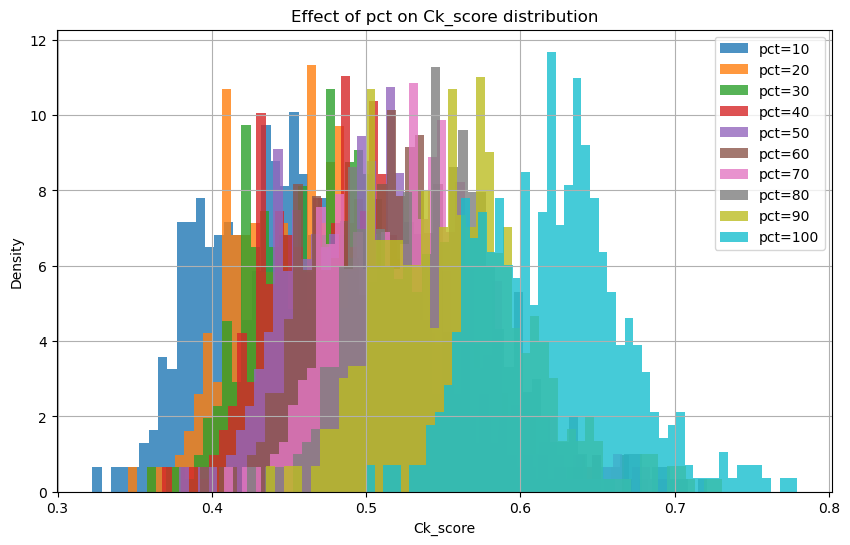

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Extract and flatten Ck data
Ck_data = SurfaceFitdf9[[x for x in SurfaceFitdf9.columns if 'Ck_' in x]]
Ck_flat = Ck_data.values.flatten()

# Percentiles to test
pcts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

plt.figure(figsize=(10, 6))

for pct in pcts:
    s = np.percentile(Ck_flat, pct)
    Ck_score = 1 / (1 + (Ck_data / s))
    Ck_score_flat = Ck_score.values.flatten()

    print(f'{pct}-IQR: {np.percentile(Ck_score, 75)-np.percentile(Ck_score, 25):.4f}', f'R: {np.max(Ck_score)-np.min(Ck_score):.4f}')

    # Plot distribution
    plt.hist(Ck_score_flat, bins=50, alpha=0.8, density=True, label=f'pct={pct}')

plt.title('Effect of pct on Ck_score distribution')
plt.xlabel('Ck_score')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


## Average distance of saddle centre from trapezium centre

In [13]:
total = 0
for i in tqdm(range(n_joints)):

    # get saddle mesh
    saddle_file = saddle_mesh_files[i]
    saddle_filepath = os.path.join(saddle_mesh_path, saddle_file)
    saddle_mesh = pv.read(saddle_filepath).extract_geometry()

    # get subject info
    subject_info = get_info_dict(info, saddle_file.split('-')[0], saddle_file.split('-')[1])[0]
    # change to tpm coords so don't need to scale coords (also gives good even grid for visuals) (and gives best R2)
    stl_path = os.path.join(db_path, subject_info['path'])
    tpm_centroid, _, tpm_axes = inertia_data('tpm', get_inertia(stl_path))

    # measure distance of saddle from centroid
    saddle_centre_idx = saddle_mesh.find_closest_point(get_centroid(saddle_mesh.faces.reshape(-1, 4), saddle_mesh.points))
    saddle_centre_coord = saddle_mesh.points[saddle_centre_idx]
    total += np.linalg.norm(saddle_centre_coord - tpm_centroid)
centre_avg = total / n_joints

  0%|          | 0/46 [00:00<?, ?it/s]

100%|██████████| 46/46 [00:39<00:00,  1.15it/s]


In [ ]:
centre_avg # so set centroid to (0,0,5)???

5.558015446612696